In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

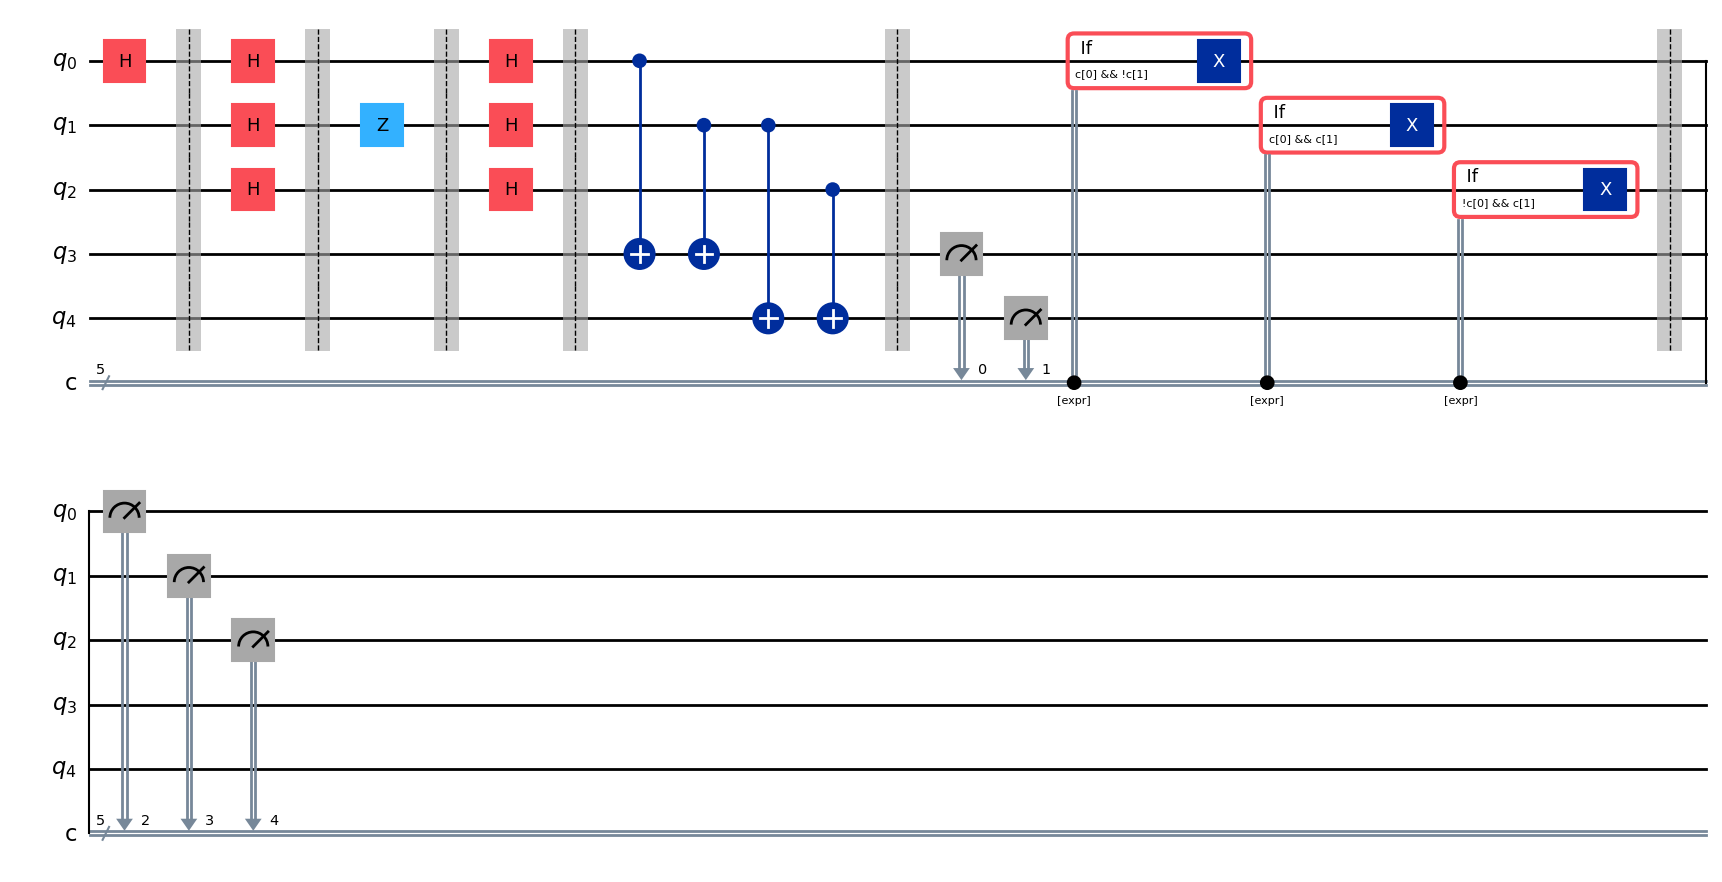

In [4]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.

phase = QuantumCircuit(5,5)

# qubit 0 is the one we are trying to send
# qubits 1 and 2 are used for the encoding
# qubits 3 and 4 are used for the error syndrome
# classical bits 0 and 1 are used for the syndrome measurement
# classical bits 2, 3 and 4 are for a final measurement to check the statistics

phase.h(0)

# Introduce barriers to help with visualisation

phase.barrier()

# Change basis to X-basis to protect against phase flips
phase.h(0)
phase.h(1)
phase.h(2)

# Another barrier

phase.barrier()


phase.z(1)

# Another barrier

phase.barrier()

# 4. Decoding (Change basis back to Z-basis), converts the Z error to an X error

phase.h(0)
phase.h(1)
phase.h(2)

phase.barrier()

# Syndrome measurements
phase.cx(0, 3)
phase.cx(1, 3)
phase.cx(1, 4)
phase.cx(2, 4)

phase.barrier()

phase.measure([3,4],[0,1])

# Conditional application of X to qubits 0, 1 and 2
# if c0 and not c1 then X(q0)
# if c0 and c1 then X(q1)
# if not c0 and c1 then X(q2)

with phase.if_test(expr.logic_and(phase.clbits[0],expr.logic_not(phase.clbits[1]))):
    phase.x(0)

with phase.if_test(expr.logic_and(phase.clbits[0],phase.clbits[1])):
    phase.x(1)

with phase.if_test(expr.logic_and(expr.logic_not(phase.clbits[0]),phase.clbits[1])):
    phase.x(2)

phase.barrier()

# The original state of qubit 0 was encoded by being "spread" across qubits 1 and 2.
# We are now back in that encoded state.
# Because of the entanglement, measuring qubits 0, 1 and 2
# should give the same statistics as measuring the original qubit 0.

# You can also implement the final decoding, putting the state back into a single qubit, and measuring it.

phase.measure([0,1,2],[2,3,4])

# Check the circuit

phase.draw("mpl")



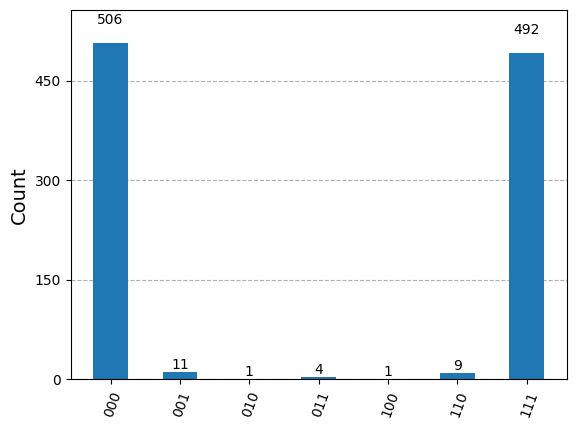

In [5]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(phase, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)